In [1]:
pip install jax dynamax equinox seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
import os
current_dir = os.path.dirname(os.path.abspath('__file__'))
parent_dir = os.path.dirname(current_dir)
sys.path.insert(0, parent_dir)
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import seaborn as sns
from jax import grad, jit, vmap, lax
from jaxtyping import Array, Float
from typing import Callable
from tensorflow_probability.substrates import jax as tfp
import equinox as eqx
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

tfd = tfp.distributions
tfb = tfp.bijectors
MVN = tfd.MultivariateNormalFullCovariance
MVNDiag = tfd.MultivariateNormalDiag

from dynamax import hidden_markov_model as hmm
from dynamax import linear_gaussian_ssm as lgssm
from models import SLDS
from slds_eqx.gibbs import fit_gibbs

# random seed for reproducibility
key = jr.PRNGKey(0)


In [3]:
def create_transition_matrix(num_states):
    p = (jnp.arange(num_states)**10).astype(float)
    p = p / p.sum()
    indices = (jnp.arange(num_states)[:, None] - jnp.arange(num_states)[None, :]) % num_states
    P = p[indices]
    return P

In [4]:
# Data Generation
def generate_synthetic_data(key, num_states, latent_dim, emission_dim, num_timesteps):
    # Create transition matrix
    # p = jnp.arange((num_states)**10).astype(float) 
    # p /= p.sum()
    # P = jnp.zeros((num_states, num_states))
    # for k, p in enumerate(p[::-1]):
    #     #jnp.eye creates identity matrix which is scaled by p
    #     # jnp.roll shifts it k columns to the right to put it k steps above main diagonal
    #     # results in transiton matrix where highest prob is on main diagonal - nearby state transitions are more likely
    #     P += jnp.roll(p * jnp.eye(num_states), k, axis=1)
    indices = jnp.arange(num_states)
    probs = jnp.power(num_states - indices, 10)
    probs = probs / probs.sum()
    
    P = jnp.zeros((num_states, num_states))
    for k in range(num_states):
        P += jnp.roll(probs[k] * jnp.eye(num_states), k, axis=1)
    print(P)
    plt.imshow(P, vmin=0, vmax=1, cmap="Greys")
    plt.xlabel("next state")
    plt.ylabel("current state")
    plt.title("transition matrix")
    plt.colorbar()
    #print("Transition matrix created")
    #Create dynamics matrices
    rot = lambda theta: jnp.array([[jnp.cos(theta), -jnp.sin(theta)],
                                   [jnp.sin(theta), jnp.cos(theta)]])
    angles = jnp.linspace(0, 2 * jnp.pi, num_states, endpoint=False)
    theta = -jnp.pi / 25
    As = jnp.array([0.8 * rot(theta) for _ in range(num_states)])
    bs = jnp.column_stack([jnp.cos(angles), jnp.sin(angles)])
    Qs = jnp.tile(0.001 * jnp.eye(latent_dim), (num_states, 1, 1))

    #print("Dynamics matrices created")

    # Create emission matrix
    key, subkey = jr.split(key)
    C = jr.normal(subkey, (emission_dim, latent_dim))
    d = jnp.zeros(emission_dim)
    R = jnp.eye(emission_dim)

    #print("Emission matrix created")

    # Create SLDS model
    log_P = tfb.SoftmaxCentered().inverse(P+1e-4)#
    log_Qs = tfb.Softplus(low=1e-5).inverse(vmap(jnp.diag)(Qs))
    log_R = tfb.Softplus(low=1e-5).inverse(jnp.diag(R))
    print("log_P:", log_P)
    print("log_Qs:", log_Qs)
    print("log_R:", log_R)
    true_slds = SLDS(num_states, latent_dim, emission_dim, log_P, As, bs, log_Qs, C, d, log_R)
    #print("SLDS model created")
    
    # Sample from the model
    key, subkey = jr.split(key)
    zs, xs, ys = true_slds.sample(subkey, num_timesteps)
    return true_slds, zs, xs, ys

[[8.980484e-01 9.642721e-02 5.430155e-03 9.416720e-05 9.196015e-08]
 [9.196015e-08 8.980484e-01 9.642721e-02 5.430155e-03 9.416720e-05]
 [9.416720e-05 9.196015e-08 8.980484e-01 9.642721e-02 5.430155e-03]
 [5.430155e-03 9.416720e-05 9.196015e-08 8.980484e-01 9.642721e-02]
 [9.642721e-02 5.430155e-03 9.416720e-05 9.196015e-08 8.980484e-01]]
log_P: [[ 9.102001   6.871491   4.011882   0.6626301]
 [-0.6626301  8.439371   6.208861   3.3492517]
 [-3.3492517 -4.011882   5.0901194  2.8596091]
 [-2.8596091 -6.208861  -6.871491   2.2305102]
 [-2.2305102 -5.0901194 -8.439371  -9.102001 ]]
log_Qs: [[-6.9173107 -6.9173107]
 [-6.9173107 -6.9173107]
 [-6.9173107 -6.9173107]
 [-6.9173107 -6.9173107]
 [-6.9173107 -6.9173107]]
log_R: [0.541309 0.541309 0.541309 0.541309 0.541309 0.541309 0.541309 0.541309
 0.541309 0.541309]


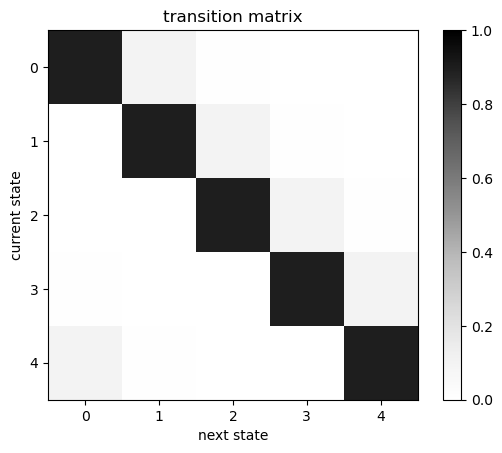

In [5]:
num_states, latent_dim, emission_dim, num_timesteps = 5, 2, 10, 5000
key, subkey = jr.split(key)
true_slds, true_zs, true_xs, ys = generate_synthetic_data(subkey, num_states, latent_dim, emission_dim, num_timesteps)

In [6]:
print(f"Logits: {true_slds.transition_logits}")

Logits: [[ 9.102001   6.871491   4.011882   0.6626301]
 [-0.6626301  8.439371   6.208861   3.3492517]
 [-3.3492517 -4.011882   5.0901194  2.8596091]
 [-2.8596091 -6.208861  -6.871491   2.2305102]
 [-2.2305102 -5.0901194 -8.439371  -9.102001 ]]


In [7]:
print(true_zs.shape)
print(true_xs.shape)
print(ys.shape)

(5000,)
(5000, 2)
(5000, 10)


In [8]:
# plt.figure()
# plt.imshow(ys[0].T, aspect="auto", interpolation="None")
# plt.colorbar()

In [9]:
# fig = plt.figure(figsize=(8, 8))
# for k in range(num_states):
#     plt.plot(*xs[zs==k].T, 'o', color=colors[k],
#          alpha=0.75, markersize=3)

# plt.plot(*xs[:1000].T, '-k', lw=0.5, alpha=0.2)
# plt.xlabel("$x_1$")
# plt.ylabel("$x_2$")

In [10]:
# def plot_states_and_timeseries(zs, vs, vs_std=None, spc=5):
#     T, dim = vs.shape
#     fig, ax = plt.subplots(1, 1, figsize=(8, 4))
#     ax.imshow(zs[None, :],
#               extent=(0, T, -spc, dim * spc),
#               cmap=cmap,
#               alpha=0.5,
#               aspect="auto",
#               vmax=len(colors)-1)
#     ax.plot(vs + spc * jnp.arange(dim), '-k', lw=1)
#     if vs_std is not None:
#         for d in range(dim):
#             ax.fill_between(jnp.arange(T),
#                             vs[:, d] + spc * d - 2 * vs_std[:, d],
#                             vs[:, d] + spc * d + 2 * vs_std[:, d],
#                             color='k', alpha=0.25,
#                             )
#     ax.set_ylim(-spc, dim * spc)
#     ax.set_yticks(jnp.arange(dim) * spc)
#     ax.set_yticklabels(jnp.arange(dim))
#     return fig, ax

# fig, ax = plot_states_and_timeseries(zs[0], xs[0])
# ax.set_xlim(0, 200)
# ax.set_title("latent states")

# fig, ax = plot_states_and_timeseries(zs[0], ys[0])
# ax.set_xlim(0, 200)
# ax.set_title("emissions")

In [11]:
#Intiliaze the model
def initialize_model(key, true_slds):
    # Slightly perturb the true parameters
    perturb = lambda x: x + 0.1 * jr.normal(key, x.shape)
    init_slds = SLDS(
        true_slds.num_states,
        true_slds.latent_dim,
        true_slds.emission_dim,
        perturb(true_slds.transition_logits),
        perturb(true_slds.dynamics_matrices),
        perturb(true_slds.dynamics_biases),
        perturb(true_slds.dynamics_diag_logvars),
        perturb(true_slds.emission_matrix),
        perturb(true_slds.emission_bias),
        perturb(true_slds.emission_diag_logvars)
    )
    return init_slds

In [12]:
key, subkey = jr.split(key)
init_slds = initialize_model(subkey, true_slds)

In [13]:
print(f"Logits: {init_slds.transition_logits}")

# [[ 9.102001   6.871491   4.011882   0.6626301]
#  [-0.6626301  8.439371   6.208861   3.3492517]
#  [-3.3492517 -4.011882   5.0901194  2.8596091]
#  [-2.8596091 -6.208861  -6.871491   2.2305102]
#  [-2.2305102 -5.0901194 -8.439371  -9.102001 ]]

Logits: [[ 9.022181   6.7784104  3.9377522  0.6302688]
 [-0.6063907  8.590682   6.1808634  3.4474275]
 [-3.4729836 -4.002406   4.956166   2.932794 ]
 [-2.963     -6.3887653 -6.7024355  2.3210807]
 [-2.1637304 -5.2777853 -8.479074  -9.249068 ]]


In [14]:
# Fit the model
key, subkey = jr.split(key)
fitted_slds, lps, fitted_zs, fitted_xs = fit_gibbs(
    init_slds, subkey, ys, 
    initial_zs=jnp.asarray(jr.randint(subkey, (num_timesteps,), 0, num_states), dtype=jnp.int32),
    initial_xs=jr.normal(subkey, (num_timesteps, latent_dim)),
    num_iters=100, lr=1e-3, reg_schedule=lambda t: 1.0 * (0.99 ** t),
    param_update_iters=10
)

Type of zs: <class 'tuple'>


TracerArrayConversionError: The numpy.ndarray conversion method __array__() was called on traced array with shape float32[].
The error occurred while tracing the function _step at /Users/agam/dynamax-slds/dynamax/slds_eqx/gibbs.py:182 for scan. This concrete value was not available in Python because it depends on the values of the arguments carry[1], carry[2].transition_logits, carry[2].dynamics_matrices, carry[2].dynamics_biases, carry[2].dynamics_diag_logvars, and carry[4].
See https://jax.readthedocs.io/en/latest/errors.html#jax.errors.TracerArrayConversionError

In [ ]:
def compare_parameters(true_slds, fitted_slds):
    print("Transition Matrix:")
    print("True:", true_slds.transition_matrix)
    print("Fitted:", fitted_slds.transition_matrix)
    print("\nDynamics Matrices:")
    print("True:", true_slds.dynamics_matrices)
    print("Fitted:", fitted_slds.dynamics_matrices)
    print("\nEmission Matrix:")
    print("True:", true_slds.emission_matrix)
    print("Fitted:", fitted_slds.emission_matrix)

In [ ]:
compare_parameters(true_slds, fitted_slds)

In [ ]:
# Discrete State Inference
# nmi compares mutual dependence and ari measures similarity in data clusterings
nmi = normalized_mutual_info_score(true_zs, fitted_zs)
ari = adjusted_rand_score(true_zs, fitted_zs)
print(f"Normalized Mutual Information: {nmi}")
print(f"Adjusted Rand Index: {ari}")

In [ ]:
# Continuous State Inference
mse = jnp.mean((true_xs - fitted_xs)**2)
correlation = jnp.corrcoef(true_xs.ravel(), fitted_xs.ravel())[0, 1]
print(f"Mean Squared Error: {mse}")
print(f"Correlation: {correlation}")

In [ ]:
#Log Probability Trajectory
plt.figure(figsize=(10, 5))
plt.plot(lps)
plt.xlabel("Iteration")
plt.ylabel("Log Probability")
plt.title("Log Probability Trajectory")
plt.show()

In [ ]:
# Visualize the results
def plot_states_and_timeseries(zs, xs, title):
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.imshow(zs[None, :], aspect="auto", cmap="Set3", interpolation="nearest")
    ax.plot(xs[:, 0], color="r", alpha=0.5)
    ax.plot(xs[:, 1], color="b", alpha=0.5)
    ax.set_title(title)
    plt.show()

In [ ]:
plot_states_and_timeseries(true_zs, true_xs, "True States")
plot_states_and_timeseries(fitted_zs, fitted_xs, "Fitted States")

In [ ]:
# Checking for consistency across multiple runs
def run_multiple_fits(num_runs):
    results = []
    for i in range(num_runs):
        key = jr.PRNGKey(i)
        init_slds = initialize_model(key, true_slds)
        fitted_slds, lps, _, _ = fit_gibbs(init_slds, key, ys, 
                                           initial_zs=jr.randint(key, (num_timesteps,), 0, num_states),
                                           initial_xs=jr.normal(key, (num_timesteps, latent_dim)),
                                           num_iters=100)
        results.append(lps[-1])  # Final log probability
    return results

In [ ]:
multiple_run_results = run_multiple_fits(10)
plt.figure(figsize=(10, 5))
plt.boxplot(multiple_run_results)
plt.title("Distribution of Final Log Probabilities Across Multiple Runs")
plt.show()

In [ ]:
# Checking performance with different initializations
def run_with_different_initializations():
    results = []
    for scale in [0.1, 1.0, 10.0]:
        key = jr.PRNGKey(int(scale * 100))
        perturb = lambda x: x + scale * jr.normal(key, x.shape)
        init_slds = SLDS(
            true_slds.num_states,
            true_slds.latent_dim,
            true_slds.emission_dim,
            perturb(true_slds.transition_logits),
            perturb(true_slds.dynamics_matrices),
            perturb(true_slds.dynamics_biases),
            perturb(true_slds.dynamics_diag_logvars),
            perturb(true_slds.emission_matrix),
            perturb(true_slds.emission_bias),
            perturb(true_slds.emission_diag_logvars)
        )
        fitted_slds, lps, _, _ = fit_gibbs(init_slds, key, ys, 
                                           initial_zs=jr.randint(key, (num_timesteps,), 0, num_states),
                                           initial_xs=jr.normal(key, (num_timesteps, latent_dim)),
                                           num_iters=100)
        results.append((scale, lps))
    return results

In [ ]:
init_results = run_with_different_initializations()
plt.figure(figsize=(10, 5))
for scale, lps in init_results:
    plt.plot(lps, label=f"Scale: {scale}")
plt.xlabel("Iteration")
plt.ylabel("Log Probability")
plt.title("Convergence with Different Initializations")
plt.legend()
plt.show()

In [ ]:
# Sensitivity to learning rate and regularization
def run_with_different_hyperparameters():
    results = []
    for lr in [1e-4, 1e-3, 1e-2]:
        for reg_scale in [0.1, 1.0, 10.0]:
            key = jr.PRNGKey(int(lr * 1e4 + reg_scale * 10))
            reg_schedule = lambda t: reg_scale * (0.99 ** t)
            fitted_slds, lps, _, _ = fit_gibbs(init_slds, key, ys, 
                                               initial_zs=jr.randint(key, (num_timesteps,), 0, num_states),
                                               initial_xs=jr.normal(key, (num_timesteps, latent_dim)),
                                               num_iters=100, lr=lr, reg_schedule=reg_schedule)
            results.append((lr, reg_scale, lps))
    return results

In [ ]:
hyper_results = run_with_different_hyperparameters()
plt.figure(figsize=(12, 8))
for lr, reg_scale, lps in hyper_results:
    plt.plot(lps, label=f"LR: {lr}, Reg: {reg_scale}")
plt.xlabel("Iteration")
plt.ylabel("Log Probability")
plt.title("Sensitivity to Hyperparameters")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()